In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime

In [2]:
# 1. Tensor Manipulations & Reshaping
# Task: Tensor Reshaping & Operations

tensor1 = tf.random.normal(shape=(4, 6))

# Rank and Shape
tensor_rank = tf.rank(tensor1)
tensor_shape = tf.shape(tensor1)

print(f"Original Tensor Shape: {tensor_shape.numpy()}")
print(f"Original Tensor Rank: {tensor_rank.numpy()}")

# Reshape and Transpose
reshaped_tensor = tf.reshape(tensor1, shape=(2, 3, 4))
transposed_tensor = tf.transpose(reshaped_tensor, perm=[1, 0, 2])

print(f"Reshaped Tensor Shape: {reshaped_tensor.shape}")
print(f"Transposed Tensor Shape: {transposed_tensor.shape}")

# Broadcast
tensor2 = tf.constant([[1.0, 2.0, 3.0, 4.0]])
added_tensor = transposed_tensor + tensor2

print(f"Smaller Tensor Shape: {tensor2.shape}")
print(f"Resulting Tensor Shape after Addition: {added_tensor.shape}")


Original Tensor Shape: [4 6]
Original Tensor Rank: 2
Reshaped Tensor Shape: (2, 3, 4)
Transposed Tensor Shape: (3, 2, 4)
Smaller Tensor Shape: (1, 4)
Resulting Tensor Shape after Addition: (3, 2, 4)


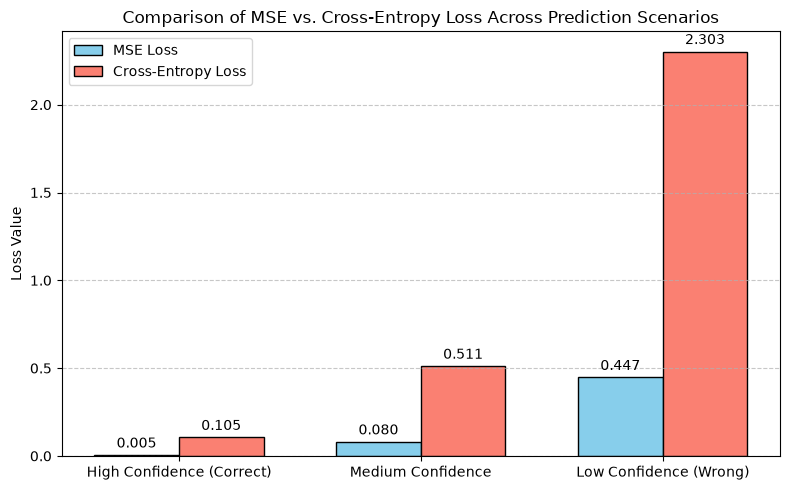

In [3]:
# 2. Loss Functions & Hyperparameter Tuning
# Task: Implement and Compare Loss Functions


y_true = np.array([1.0, 0.0, 0.0])

# Predictions representing different confidence levels
predictions = {
    "High Confidence (Correct)": np.array([0.9, 0.05, 0.05]),
    "Medium Confidence": np.array([0.6, 0.20, 0.20]),
    "Low Confidence (Wrong)": np.array([0.1, 0.70, 0.20])
}


def compute_mse(yt, yp):
    return np.mean((yt - yp) ** 2)


def compute_cce(yt, yp, epsilon=1e-15):
    yp_clipped = np.clip(yp, epsilon, 1 - epsilon)
    return -np.sum(yt * np.log(yp_clipped))


# Losses
results = {}
for key, yp in predictions.items():
    mse = compute_mse(y_true, yp)
    cce = compute_cce(y_true, yp)
    results[key] = (mse, cce)

# Bar Chart
labels = list(results.keys())
mse_values = [results[k][0] for k in labels]
cce_values = [results[k][1] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, mse_values, width,
                label='MSE Loss', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, cce_values, width,
                label='Cross-Entropy Loss', color='salmon', edgecolor='black')

ax.set_ylabel('Loss Value')
ax.set_title(
    'Comparison of MSE vs. Cross-Entropy Loss Across Prediction Scenarios')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


/Users/supriiyaaa/UCMO/Fall 2026/Neural Network/env/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


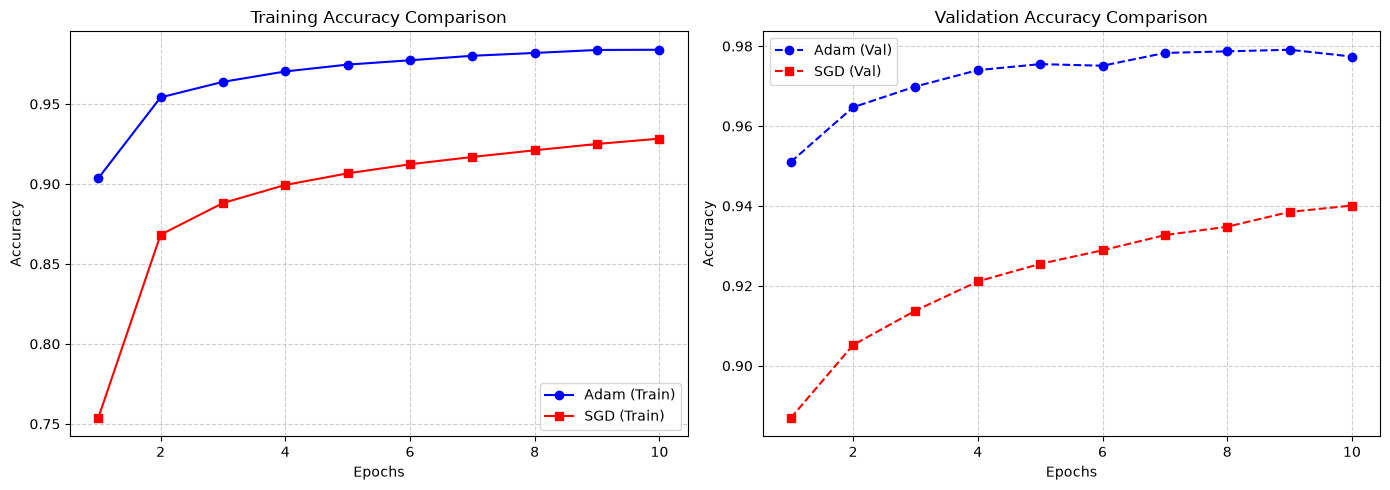

Final Adam Validation Accuracy: 0.9774
Final SGD Validation Accuracy  : 0.9401


In [4]:
# 3. Train a Model with Different Optimizers
# Task: Train MNIST Model with Adam & SGD

# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Helper function to build a standard MLP model


def build_model():
    return tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])


# Train model with Adam Optimizer
model_adam = build_model()
model_adam.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(x_train, y_train,
                              epochs=10,
                              batch_size=64,
                              validation_data=(x_test, y_test),
                              verbose=0)

# Train model with SGD Optimizer
model_sgd = build_model()
model_sgd.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(x_train, y_train,
                            epochs=10,
                            batch_size=64,
                            validation_data=(x_test, y_test),
                            verbose=0)

# Plot comparison trends
epochs = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training Accuracy Plot
ax1.plot(epochs, history_adam.history['accuracy'], 'b-o', label='Adam (Train)')
ax1.plot(epochs, history_sgd.history['accuracy'], 'r-s', label='SGD (Train)')
ax1.set_title('Training Accuracy Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Validation Accuracy Plot
ax2.plot(
    epochs, history_adam.history['val_accuracy'], 'b--o', label='Adam (Val)')
ax2.plot(
    epochs, history_sgd.history['val_accuracy'], 'r--s', label='SGD (Val)')
ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('mnist_adam_vs_sgd.png')
plt.show()

# Print Final Evaluation Scores
print(
    f"Final Adam Validation Accuracy: {history_adam.history['val_accuracy'][-1]:.4f}")
print(
    f"Final SGD Validation Accuracy  : {history_sgd.history['val_accuracy'][-1]:.4f}")


In [5]:
# 4. Train a Neural Network and Log to TensorBoard

# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values from [0, 255] to [0.0, 1.0]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build a simple neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Configure TensorBoard callback with timestamped log directory
log_dir = os.path.join(
    "logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir, histogram_freq=1)

# Train the model for 5 epochs with TensorBoard logging
print(f"Training model... Logs will be saved to: {log_dir}")
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_data=(x_test, y_test),
                    callbacks=[tensorboard_callback])

Training model... Logs will be saved to: logs/fit/20260908-170547
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step - accuracy: 0.9043 - loss: 0.3342 - val_accuracy: 0.9520 - val_loss: 0.1608
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 839us/step - accuracy: 0.9538 - loss: 0.1596 - val_accuracy: 0.9668 - val_loss: 0.1112
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - accuracy: 0.9641 - loss: 0.1206 - val_accuracy: 0.9715 - val_loss: 0.0932
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.9697 - loss: 0.0986 - val_accuracy: 0.9762 - val_loss: 0.0786
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - accuracy: 0.9743 - loss: 0.0840 - val_accuracy: 0.9772 - val_loss: 0.0746
